# What makes a filing unusual?

This notebook asks a narrow question: once the feature-generation prototype
turns a Form 990 filing into measures of scale, staffing, grants, lobbying,
related-organization activity, and organizational change, do some filings
look meaningfully different from their peers?

The answer is intended to be a review list, not a verdict. DBSCAN looks for
dense groups and labels rows outside those groups as noise. Isolation Forest
ranks rows that are easier to separate from the rest of the population. A
filing can be unusual because it is large, because it uses a different form,
because its schedules are unusually complete, or because it contains a
genuine operating pattern worth investigating. The models cannot tell those
explanations apart on their own.

The database contains the full 2023-2024 comparison population, but this
notebook defaults to a deterministic, year-balanced cohort so the entire
feature-generation and clustering workflow can be rerun on a laptop. The
full population remains visible in the coverage table below. Set
`COHORT_SIZE = None` in the configuration cell to run every complete row;
that is a larger, slower run rather than a different definition of the
data. The written interpretation at the end of this saved notebook
describes the default 20,000-row run; changing the setting requires a
fresh run and a fresh reading of the results.

The transparency index is carried along as descriptive context; it is not
a target and does not define what counts as an anomaly. The central story
is therefore about heterogeneity in reporting and organizational
operations, not about automatically detecting hidden activity.

The project also has 344 validated OpenSecrets EIN labels. I use those
labels only after the unsupervised models are fit, as a weak external
check on retrieval. They identify organizations that appeared in the
project's historical OpenSecrets matching workflow; they are not a
complete set of dark-money organizations and they are not negative labels.

The model is pooled across the two filing years. That makes the first
comparison broad, but it also means that a flag can reflect a change in
reporting between years. The year-by-form tables below keep that
limitation visible.


In [1]:
from pathlib import Path
import sqlite3
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
DB_PATH = ROOT / 'data' / 'irs990_full.db'
if not DB_PATH.exists():
    raise FileNotFoundError(f'Database not found: {DB_PATH}')

from analysis.modeling import (
    dbscan_clusters,
    dbscan_k_distances,
    isolation_forest_anomalies,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)

MODEL_YEARS = (2023, 2024)
YEAR_LABEL = '2023-2024'
COHORT_SIZE = 20_000
RANDOM_STATE = 42
ISOLATION_CONTAMINATION = 0.05
MIN_SAMPLES = 10
OPENSECRETS_LABEL_PATH = (
    ROOT / 'materials' / 'OpenSecrets Pipeline'
    / '03_dark_money_labels.csv'
)

print(f'Database: {DB_PATH}')
scope_description = (
    'full complete score population'
    if COHORT_SIZE is None
    else f'{COHORT_SIZE:,}-row year-balanced cohort'
)
print(
    f'Modeling scope: tax_years={YEAR_LABEL}, {scope_description}'
)


Database: /home/mattgroho/github/influence-network/data/irs990_full.db
Modeling scope: tax_years=2023-2024, 20,000-row year-balanced cohort


## 1. Build the comparison population

The latest transparency-index run supplies a complete, reproducible filing
cohort and useful context columns. I then rebuild the baseline features from
the source filing and schedule tables rather than using stored model labels.
Child-table aggregations are restricted to the cohort through a temporary
SQLite table.

When the bounded setting is used, all available labeled rows are retained
first. The remaining rows are selected separately within each year so the
comparison has 10,000 filings from 2023 and 10,000 from 2024. This is a
deliberate modeling design, not an estimate of the two years' population
shares. With `COHORT_SIZE = None`, this selection step is skipped and the
complete score population flows into the feature table.

The bound is practical rather than statistical. The full population has
1,357,390 rows. After feature imputation and missingness indicators, the
model matrix is wide and dense; DBSCAN also builds neighborhood
structures that can grow much faster than the input table. Running every
row is possible on a suitably provisioned machine, but it is not a
reasonable default for a notebook intended to be portable and easy to
rerun.

This matters because the models compare filings with one another. Before
asking which rows are unusual, we need to know which forms dominate the
population and which schedules are commonly absent.


In [2]:
OUT_TYPES = ('B', 'D', 'G', 'J', 'L', 'P', 'R')
IN_TYPES = ('C', 'E', 'H', 'K', 'M', 'Q', 'S')
BETWEEN_TYPES = ('I', 'N', 'O')

if not OPENSECRETS_LABEL_PATH.exists():
    raise FileNotFoundError(
        f'OpenSecrets label file not found: {OPENSECRETS_LABEL_PATH}'
    )
open_secrets_labels = pd.read_csv(
    OPENSECRETS_LABEL_PATH, dtype={'filer_ein': 'string'}
)
open_secrets_labels['ein'] = (
    pd.to_numeric(open_secrets_labels['filer_ein'], errors='coerce')
    .astype('Int64')
    .astype('string')
    .str.zfill(9)
)
if open_secrets_labels['ein'].isna().any():
    raise ValueError('OpenSecrets labels contain an invalid EIN')
if open_secrets_labels['ein'].duplicated().any():
    raise ValueError('OpenSecrets labels must contain one row per EIN')
open_secrets_labels = open_secrets_labels.rename(
    columns={'filer_name': 'opensecrets_name'}
)
open_secrets_labels['open_secrets_known_label'] = True

with sqlite3.connect(DB_PATH) as connection:
    run_row = connection.execute(
        'SELECT run_id, index_version FROM transparency_index_scores '
        'ORDER BY generated_at DESC LIMIT 1'
    ).fetchone()
    if run_row is None:
        raise ValueError('No transparency-index score run is available')
    run_id, index_version = run_row

    score_population = pd.read_sql_query(
        '''
        SELECT s.filing_id, s.ein, s.tax_year
        FROM transparency_index_scores AS s
        WHERE s.run_id = ?
          AND s.tax_year IN (?, ?)
          AND s.complete = 1
        ORDER BY s.filing_id
        ''',
        connection,
        params=(run_id, *MODEL_YEARS),
    )
    score_population['open_secrets_known_label'] = (
        score_population['ein'].isin(open_secrets_labels['ein'])
    )
    labeled_population = score_population.loc[
        score_population['open_secrets_known_label']
    ]
    if labeled_population.empty:
        raise ValueError(
            'No OpenSecrets-labeled score rows found for the selected years'
        )
    if COHORT_SIZE is None:
        cohort = score_population.copy()
    else:
        if COHORT_SIZE < len(MODEL_YEARS):
            raise ValueError(
                'COHORT_SIZE must be at least the number of model years'
            )
        target_rows_by_year = {
            tax_year: COHORT_SIZE // len(MODEL_YEARS)
            + int(position < COHORT_SIZE % len(MODEL_YEARS))
            for position, tax_year in enumerate(MODEL_YEARS)
        }
        cohort_parts = []
        for tax_year in MODEL_YEARS:
            year_labeled = labeled_population.loc[
                labeled_population['tax_year'].eq(tax_year)
            ]
            year_unlabeled = score_population.loc[
                score_population['tax_year'].eq(tax_year)
                & ~score_population['open_secrets_known_label']
            ]
            target_rows = target_rows_by_year[tax_year]
            if len(year_labeled) > target_rows:
                raise ValueError(
                    f'{tax_year} has {len(year_labeled):,} labeled rows, '
                    f'exceeding its {target_rows:,}-row cohort target'
                )
            cohort_parts.append(
                pd.concat(
                    [
                        year_labeled,
                        year_unlabeled.head(
                            target_rows - len(year_labeled)
                        ),
                    ],
                    ignore_index=True,
                )
            )
        cohort = pd.concat(
            cohort_parts, ignore_index=True
        ).sort_values('filing_id')
        if len(cohort) != COHORT_SIZE:
            raise ValueError(
                f'Expected a {COHORT_SIZE:,}-row cohort, '
                f'found {len(cohort):,}'
            )

    connection.execute(
        'CREATE TEMP TABLE modeling_cohort '
        '(filing_id INTEGER PRIMARY KEY)'
    )
    connection.executemany(
        'INSERT INTO modeling_cohort (filing_id) VALUES (?)',
        ((int(filing_id),) for filing_id in cohort['filing_id']),
    )

    features_base_df = pd.read_sql_query(
        '''
        SELECT
            s.run_id,
            s.index_version,
            s.filing_id,
            s.ein,
            s.tax_year,
            s.index_score,
            s.observed_components,
            s.complete,
            s.board_members,
            s.volunteers,
            s.related_to_527s,
            s.related_to_c3s,
            s.political_expenses,
            s.total_salaries,
            s.unrestricted_net_assets,
            s.fundraising_expenses,
            f.filer_name,
            f.form_type,
            f.exempt_organization_type,
            f.mission,
            f.total_revenue,
            f.total_expenses,
            f.total_assets,
            f.grants_and_contributions,
            f.voting_members_governing_body,
            f.voting_members_independent,
            f.political_activity_flag,
            f.filer_address_line1,
            f.filer_address_line2,
            f.filer_city,
            f.filer_state,
            f.filer_zip,
            f.filer_zip_code,
            f.doing_business_as_name
        FROM transparency_index_scores AS s
        JOIN modeling_cohort AS c ON c.filing_id = s.filing_id
        JOIN irs990_filings AS f ON f.filing_id = s.filing_id
        WHERE s.run_id = ?
        ''',
        connection,
        params=(run_id,),
    )

    contractors = pd.read_sql_query(
        '''
        SELECT
            x.filing_id,
            COUNT(x.line_no) AS num_contractors,
            SUM(x.compensation) AS total_contractor_comp,
            AVG(x.compensation) AS mean_contractor_comp
        FROM irs990_filing_contractors AS x
        JOIN modeling_cohort AS c ON c.filing_id = x.filing_id
        WHERE lower(trim(x.contractor_name))
            NOT IN ('na', 'none', 'n/a', 'n a')
        GROUP BY x.filing_id
        ''',
        connection,
    )

    grants = pd.read_sql_query(
        '''
        SELECT
            x.filing_id,
            COUNT(x.line_no) AS num_grants,
            SUM(x.amount) AS total_granted,
            AVG(x.amount) AS avg_granted
        FROM irs990_filing_grants AS x
        JOIN modeling_cohort AS c ON c.filing_id = x.filing_id
        GROUP BY x.filing_id
        ''',
        connection,
    )

    lobbying = pd.read_sql_query(
        '''
        SELECT
            x.filing_id,
            MAX(x.total_lobbying_expenditures_amt)
                AS total_lobbying_expenditures_amt,
            MAX(x.fees_for_services_lobbying_amt)
                AS fees_for_services_lobbying_amt
        FROM irs990_filing_lobbying AS x
        JOIN modeling_cohort AS c ON c.filing_id = x.filing_id
        GROUP BY x.filing_id
        ''',
        connection,
    )

    transactions = pd.read_sql_query(
        f'''
        WITH per_related_org AS (
            SELECT
                x.filing_id,
                x.related_org_name,
                SUM(CASE WHEN x.type IN ({','.join('?' for _ in OUT_TYPES)})
                    THEN 1 ELSE 0 END) AS num_out_transactions,
                SUM(CASE WHEN x.type IN ({','.join('?' for _ in OUT_TYPES)})
                    THEN COALESCE(x.amount, 0) ELSE 0 END) AS sum_out_transactions,
                SUM(CASE WHEN x.type IN ({','.join('?' for _ in OUT_TYPES)})
                    THEN COALESCE(x.amount, 0) ELSE 0 END)
                    / NULLIF(SUM(CASE WHEN x.type IN ({','.join('?' for _ in IN_TYPES)})
                    THEN COALESCE(x.amount, 0) ELSE 0 END)
                    + SUM(CASE WHEN x.type IN ({','.join('?' for _ in BETWEEN_TYPES)})
                    THEN COALESCE(x.amount, 0) ELSE 0 END) + 1.0, 0)
                    AS passthrough,
                SUM(CASE WHEN x.type IN ({','.join('?' for _ in IN_TYPES)})
                    THEN 1 ELSE 0 END) AS num_in_transactions,
                SUM(CASE WHEN x.type IN ({','.join('?' for _ in IN_TYPES)})
                    THEN COALESCE(x.amount, 0) ELSE 0 END) AS sum_in_transactions,
                SUM(CASE WHEN x.type IN ({','.join('?' for _ in BETWEEN_TYPES)})
                    THEN 1 ELSE 0 END) AS num_between_transactions,
                SUM(CASE WHEN x.type IN ({','.join('?' for _ in BETWEEN_TYPES)})
                    THEN COALESCE(x.amount, 0) ELSE 0 END) AS sum_between_transactions
            FROM irs990_filing_related_org_transactions AS x
            JOIN modeling_cohort AS c ON c.filing_id = x.filing_id
            WHERE x.type NOT IN ('A', 'F')
            GROUP BY x.filing_id, x.related_org_name
        ),
        transaction_rows AS (
            SELECT
                filing_id,
                passthrough,
                num_out_transactions + num_in_transactions
                    + num_between_transactions AS transactions
            FROM per_related_org
        )
        SELECT
            filing_id,
            MIN(passthrough) AS min_passthrough,
            AVG(passthrough) AS avg_passthrough,
            MAX(passthrough) AS max_passthrough,
            SUM(passthrough) AS total_passthrough,
            MIN(transactions) AS min_trxns,
            AVG(transactions) AS avg_trxns,
            MAX(transactions) AS max_trxns,
            SUM(transactions) AS total_trxns
        FROM transaction_rows
        GROUP BY filing_id
        ''',
        connection,
        params=(
            *OUT_TYPES,
            *OUT_TYPES,
            *OUT_TYPES,
            *IN_TYPES,
            *BETWEEN_TYPES,
            *IN_TYPES,
            *IN_TYPES,
            *BETWEEN_TYPES,
            *BETWEEN_TYPES,
        ),
    )

    people = pd.read_sql_query(
        '''
        SELECT
            x.filing_id,
            SUM(x.is_indiv_trustee_or_director)
                AS num_indiv_trustee_or_director,
            SUM(x.is_institutional_trustee)
                AS num_institutional_trustees,
            SUM(x.is_officer) AS num_officers,
            SUM(x.is_key_employee) AS num_key_employees,
            SUM(x.is_former_employee) AS num_former_employees,
            MIN(x.avg_weekly_hours_worked_org)
                AS min_avg_weekly_hours_org,
            AVG(x.avg_weekly_hours_worked_org)
                AS avg_avg_weekly_hours_org,
            MAX(x.avg_weekly_hours_worked_org)
                AS max_avg_weekly_hours_org,
            MIN(x.compensation_from_org) AS min_compensation_org,
            AVG(x.compensation_from_org) AS avg_compensation_org,
            MAX(x.compensation_from_org) AS max_compensation_org,
            MIN(x.avg_weekly_hours_worked_related_org)
                AS min_avg_weekly_hours_related_org,
            AVG(x.avg_weekly_hours_worked_related_org)
                AS avg_avg_weekly_hours_related_org,
            MAX(x.avg_weekly_hours_worked_related_org)
                AS max_avg_weekly_hours_related_org,
            MIN(x.compensation_from_related_org)
                AS min_compensation_related_org,
            AVG(x.compensation_from_related_org)
                AS avg_compensation_related_org,
            MAX(x.compensation_from_related_org)
                AS max_compensation_related_org,
            MIN(x.compensation_other) AS min_compensation_other,
            AVG(x.compensation_other) AS avg_compensation_other,
            MAX(x.compensation_other) AS max_compensation_other
        FROM irs990_filing_people AS x
        JOIN modeling_cohort AS c ON c.filing_id = x.filing_id
        GROUP BY x.filing_id
        ''',
        connection,
    )

    history = pd.read_sql_query(
        '''
        WITH selected_eins AS (
            SELECT DISTINCT f.ein
            FROM irs990_filings AS f
            JOIN modeling_cohort AS c ON c.filing_id = f.filing_id
        )
        SELECT
            f.ein,
            MIN(f.tax_year) AS min_year,
            MAX(f.tax_year) AS max_year,
            COUNT(DISTINCT
                COALESCE(f.filer_address_line1, '') || ' ' ||
                COALESCE(f.filer_address_line2, '') || ' ' ||
                COALESCE(f.filer_city, '') || ' ' ||
                COALESCE(f.filer_state, '') || ' ' ||
                COALESCE(f.filer_zip, f.filer_zip_code, '')
            ) AS unique_addresses,
            COUNT(DISTINCT NULLIF(
                trim(f.doing_business_as_name), ''
            )) AS unique_dbas,
            COUNT(DISTINCT NULLIF(
                upper(trim(f.filer_name)), ''
            )) AS unique_names
        FROM irs990_filings AS f
        JOIN selected_eins AS e ON e.ein = f.ein
        GROUP BY f.ein
        ''',
        connection,
    )

features_base_df['has_mission'] = (
    features_base_df['mission'].notna().astype('int8')
)
features_base_df['mission_words'] = (
    features_base_df['mission'].str.split().str.len()
)
revenue = pd.to_numeric(features_base_df['total_revenue'], errors='coerce')
grants_contributions = pd.to_numeric(
    features_base_df['grants_and_contributions'], errors='coerce'
)
features_base_df['grants_as_rev_frac'] = (
    grants_contributions / revenue
).where(revenue.notna() & revenue.ne(0), 0.0)
voting_members = pd.to_numeric(
    features_base_df['voting_members_governing_body'], errors='coerce'
)
independent_members = pd.to_numeric(
    features_base_df['voting_members_independent'], errors='coerce'
)
features_base_df['perc_ind_voting_members'] = (
    independent_members / voting_members
).where(voting_members.notna() & voting_members.ne(0))

features = features_base_df.merge(contractors, on='filing_id', how='left')
features = features.merge(grants, on='filing_id', how='left')
features = features.merge(lobbying, on='filing_id', how='left')
features = features.merge(history, on='ein', how='left')
features = features.merge(transactions, on='filing_id', how='left')
features = features.merge(people, on='filing_id', how='left')
features = features.merge(
    open_secrets_labels[
        ['ein', 'opensecrets_name', 'open_secrets_known_label']
    ],
    on='ein',
    how='left',
)
features['open_secrets_known_label'] = (
    features['open_secrets_known_label']
    .astype('boolean')
    .fillna(False)
    .astype(bool)
)

total_expenses = pd.to_numeric(features['total_expenses'], errors='coerce')
contractor_comp = pd.to_numeric(
    features['total_contractor_comp'], errors='coerce'
)
features['contractor_compensation_frac'] = (
    contractor_comp / total_expenses
).where(total_expenses.gt(0))

history_years = (
    features['max_year'] - features['min_year'] + 1
).clip(lower=1)
for count_column, output_column in (
    ('unique_addresses', 'lifetime_avg_address_changes'),
    ('unique_dbas', 'lifetime_avg_unique_dbas'),
    ('unique_names', 'lifetime_avg_unique_names'),
):
    features[output_column] = (
        (features[count_column] - 1).clip(lower=0) / history_years
    )

form_flags = pd.get_dummies(
    features['form_type'], prefix='form', dtype='int8'
)
for form_column in ('form_990', 'form_990EZ', 'form_990PF'):
    if form_column not in form_flags:
        form_flags[form_column] = 0
features = pd.concat([features, form_flags], axis=1)
numeric_columns = features.select_dtypes(include=[np.number]).columns
features[numeric_columns] = features[numeric_columns].mask(
    np.isinf(features[numeric_columns]), np.nan
)

print(
    f'Loaded score run {run_id} ({index_version}); '
    f'generated {len(features):,} rows and {features.shape[1]:,} columns.'
)
print(
    'Child-table rows: '
    f'contractors={len(contractors):,}, grants={len(grants):,}, '
    f'transactions={len(transactions):,}, people={len(people):,}.'
)
print(
    'Cohort rows by tax year: '
    f'{cohort["tax_year"].value_counts().sort_index().to_dict()}'
)
print(
    f'OpenSecrets labels: {len(open_secrets_labels):,} total; '
    f'{int(labeled_population.shape[0]):,} included in the {YEAR_LABEL} '
    'score population and cohort.'
)


Loaded score run 20260817T130206127889Z (irvin-8-v1); generated 20,000 rows and 88 columns.
Child-table rows: contractors=392, grants=2,629, transactions=345, people=19,882.
Cohort rows by tax year: {2023: 10000, 2024: 10000}
OpenSecrets labels: 344 total; 590 included in the 2023-2024 score population and cohort.


## 2. Feature contract and first look

Before modeling, I verify row identity, score completeness, the expected
feature blocks, and missingness. Missing schedule rows are retained as
missing here; the modeling preprocessing imputes them using training-cohort
medians and adds missingness indicators.


In [3]:
required_identity = {
    'filing_id', 'ein', 'tax_year', 'filer_name', 'form_type',
    'index_score', 'complete'
}
missing_identity = required_identity - set(features.columns)
if missing_identity:
    raise ValueError(f'Missing required feature columns: {sorted(missing_identity)}')
if features['filing_id'].duplicated().any():
    raise ValueError('The baseline feature table must have one row per filing')
if not features['complete'].eq(1).all():
    raise ValueError('The modeling cohort must contain complete score rows')

feature_blocks = pd.DataFrame([
    {
        'block': 'filing and financial',
        'columns': 17,
        'description': 'form, mission, revenue, expenses, grants, lobbying',
    },
    {
        'block': 'organization history',
        'columns': 6,
        'description': 'address and filer/DBA change rates',
    },
    {
        'block': 'related transactions',
        'columns': 8,
        'description': 'pass-through and transaction-count summaries',
    },
    {
        'block': 'people and compensation',
        'columns': 18,
        'description': 'roles, hours, and compensation summaries',
    },
])
display(
    pd.DataFrame({
        'measure': ['rows', 'columns', 'unique EINs', 'tax year'],
        'value': [
            len(features),
            features.shape[1],
            features['ein'].nunique(),
            features['tax_year'].unique().tolist(),
        ],
    })
)
display(feature_blocks)

missingness = (
    features.isna().mean().mul(100).round(2)
    .rename('missing_pct')
    .to_frame()
    .sort_values('missing_pct', ascending=False)
)
display(missingness.head(20))

form_mix = (
    features.groupby('form_type', observed=False)
    .agg(rows=('filing_id', 'size'))
)
form_mix['share_of_cohort'] = form_mix['rows'] / len(features)
display(form_mix)

coverage_columns = [
    'mission',
    'total_expenses',
    'grants_and_contributions',
    'total_lobbying_expenditures_amt',
    'total_contractor_comp',
    'total_granted',
    'total_trxns',
    'avg_compensation_org',
]
coverage = pd.DataFrame({
    'feature': coverage_columns,
    'observed_rows': [
        int(features[column].notna().sum())
        for column in coverage_columns
    ],
})
coverage['observed_pct'] = coverage['observed_rows'] / len(features)
display(coverage)

label_coverage = pd.DataFrame([
    {
        'population': f'{YEAR_LABEL} complete score rows',
        'rows': len(score_population),
        'known_OpenSecrets_labels': int(
            score_population['open_secrets_known_label'].sum()
        ),
        'known_label_EINs': score_population.loc[
            score_population['open_secrets_known_label'], 'ein'
        ].nunique(),
    },
    {
        'population': (
            'modeled cohort'
            if COHORT_SIZE is not None
            else 'modeled full population'
        ),
        'rows': len(features),
        'known_OpenSecrets_labels': int(
            features['open_secrets_known_label'].sum()
        ),
        'known_label_EINs': features.loc[
            features['open_secrets_known_label'], 'ein'
        ].nunique(),
    },
])
label_coverage['known_label_rate'] = (
    label_coverage['known_OpenSecrets_labels']
    / label_coverage['rows']
)
display(label_coverage)


,measure,value
0,rows,20000
1,columns,88
2,unique EINs,16940
3,tax year,"[2023, 2024]"


,block,columns,description
0,filing and financial,17,"form, mission, revenue, expenses, grants, lobb..."
1,organization history,6,address and filer/DBA change rates
2,related transactions,8,pass-through and transaction-count summaries
3,people and compensation,18,"roles, hours, and compensation summaries"


,missing_pct
num_former_employees,100.00
filer_address_line2,100.00
total_lobbying_expenditures_amt,99.93
num_institutional_trustees,99.62
total_passthrough,98.28
min_passthrough,98.28
avg_passthrough,98.28
min_trxns,98.28
total_trxns,98.28
max_passthrough,98.28


,rows,share_of_cohort
form_type,,
990,6137,0.30685
990EZ,10666,0.53330
990PF,3197,0.15985


,feature,observed_rows,observed_pct
0,mission,16803,0.84015
1,total_expenses,19759,0.98795
2,grants_and_contributions,6137,0.30685
3,total_lobbying_expenditures_amt,14,0.00070
4,total_contractor_comp,384,0.01920
5,total_granted,2612,0.13060
6,total_trxns,345,0.01725
7,avg_compensation_org,19881,0.99405


,population,rows,known_OpenSecrets_labels,known_label_EINs,known_label_rate
0,2023-2024 complete score rows,1357390,590,306,0.000435
1,modeled cohort,20000,590,306,0.029500


## How to read the model output

These methods do not decide whether a filing is suspicious. They sort the
comparison set by a particular kind of unusualness. DBSCAN asks whether a
row belongs to a dense neighborhood; its noise rows are simply the rows
that do not meet that neighborhood rule. Isolation Forest asks which rows
are easiest to separate from the rest, and its 5% setting is a review
budget chosen for this baseline.

I therefore focus on questions the data can answer: how sensitive DBSCAN
is to its radius, how often the methods point to the same filing, whether
the flags are concentrated in one form or year, and what the flagged rows
look like in the original feature columns. The tables describe a queue for
reading, not a set of confirmed findings.

## 3. Prepare the modeling matrix

DBSCAN is distance-based, so it receives standardized features. Isolation
Forest is scale-insensitive in principle, but it uses the same imputed,
log-transformed representation so that the comparison is about the method
rather than two different feature definitions. The transparency components
and `index_score` remain review context and are not included in this
baseline matrix.

OpenSecrets labels are also excluded from the matrix. They appear only in
the comparison tables below, so the models cannot use those labels while
forming the queue.


In [4]:
MODEL_FEATURE_COLUMNS = [
    'has_mission',
    'mission_words',
    'grants_as_rev_frac',
    'perc_ind_voting_members',
    'political_activity_flag',
    'num_contractors',
    'total_contractor_comp',
    'contractor_compensation_frac',
    'mean_contractor_comp',
    'total_expenses',
    'num_grants',
    'total_granted',
    'avg_granted',
    'total_lobbying_expenditures_amt',
    'fees_for_services_lobbying_amt',
    'unique_addresses',
    'unique_dbas',
    'unique_names',
    'lifetime_avg_address_changes',
    'lifetime_avg_unique_dbas',
    'lifetime_avg_unique_names',
    'min_passthrough',
    'avg_passthrough',
    'max_passthrough',
    'total_passthrough',
    'min_trxns',
    'avg_trxns',
    'max_trxns',
    'total_trxns',
    'num_indiv_trustee_or_director',
    'num_institutional_trustees',
    'num_officers',
    'num_key_employees',
    'num_former_employees',
    'min_avg_weekly_hours_org',
    'avg_avg_weekly_hours_org',
    'max_avg_weekly_hours_org',
    'min_compensation_org',
    'avg_compensation_org',
    'max_compensation_org',
    'min_avg_weekly_hours_related_org',
    'avg_avg_weekly_hours_related_org',
    'max_avg_weekly_hours_related_org',
    'min_compensation_related_org',
    'avg_compensation_related_org',
    'max_compensation_related_org',
    'min_compensation_other',
    'avg_compensation_other',
    'max_compensation_other',
    'form_990',
    'form_990EZ',
    'form_990PF',
]
missing_model_features = set(MODEL_FEATURE_COLUMNS) - set(features.columns)
if missing_model_features:
    raise ValueError(
        f'Missing baseline model features: {sorted(missing_model_features)}'
    )

LOG_FEATURES = [
    column for column in MODEL_FEATURE_COLUMNS
    if column.startswith(('total_', 'avg_', 'max_', 'min_'))
    or column.endswith(('_comp', '_granted', '_expenses', '_trxns'))
    or column in {
        'mission_words',
        'num_contractors',
        'num_grants',
        'num_indiv_trustee_or_director',
        'num_institutional_trustees',
        'num_officers',
        'num_key_employees',
        'num_former_employees',
        'unique_addresses',
        'unique_dbas',
        'unique_names',
    }
]
raw_model_features = features[MODEL_FEATURE_COLUMNS].apply(
    pd.to_numeric, errors='coerce'
)
for column in LOG_FEATURES:
    raw_model_features[column] = np.log1p(
        raw_model_features[column].clip(lower=0)
    )

usable_features = [
    column for column in raw_model_features.columns
    if raw_model_features[column].notna().any()
]
if len(usable_features) < 2:
    raise ValueError('At least two non-empty model features are required')

imputer = SimpleImputer(strategy='median', add_indicator=True)
model_matrix = pd.DataFrame(
    imputer.fit_transform(raw_model_features[usable_features]),
    index=features.index,
    columns=imputer.get_feature_names_out(usable_features),
)
if not np.isfinite(model_matrix.to_numpy()).all():
    raise ValueError('The imputed modeling matrix contains non-finite values')

feature_contract = pd.DataFrame({
    'feature': usable_features,
    'raw_missing_pct': raw_model_features[usable_features]
        .isna().mean().mul(100).round(2).to_numpy(),
    'log_transformed': [
        column in LOG_FEATURES for column in usable_features
    ],
})
display(feature_contract)
print(
    f'Model matrix: {model_matrix.shape[0]:,} rows x '
    f'{model_matrix.shape[1]:,} columns after imputation indicators.'
)

k_distances = dbscan_k_distances(
    model_matrix, min_samples=MIN_SAMPLES, scale=True
)
eps_quantiles = pd.Series(k_distances).quantile(
    [0.90, 0.95, 0.98]
).round(3)
eps_candidates = sorted({
    max(0.05, float(value)) for value in eps_quantiles
})
if not eps_candidates:
    raise ValueError('Could not derive positive DBSCAN eps candidates')
DBSCAN_EPS = float(eps_quantiles.loc[0.95])

dbscan_sensitivity_rows = []
for eps in eps_candidates:
    result = dbscan_clusters(
        model_matrix,
        eps=eps,
        min_samples=MIN_SAMPLES,
        scale=True,
    )
    dbscan_sensitivity_rows.append({
        'eps': eps,
        'clusters': result.n_clusters,
        'noise_rows': result.noise_count,
        'noise_pct': result.noise_count / len(features),
    })
dbscan_sensitivity = pd.DataFrame(dbscan_sensitivity_rows)
dbscan_sensitivity['selected_baseline'] = (
    dbscan_sensitivity['eps'].eq(DBSCAN_EPS)
)
display(dbscan_sensitivity)

cluster_result = dbscan_clusters(
    model_matrix,
    eps=DBSCAN_EPS,
    min_samples=MIN_SAMPLES,
    scale=True,
)
anomaly_result = isolation_forest_anomalies(
    model_matrix,
    contamination=ISOLATION_CONTAMINATION,
    n_estimators=200,
    random_state=RANDOM_STATE,
)
print({
    'dbscan_eps': DBSCAN_EPS,
    'dbscan_min_samples': MIN_SAMPLES,
    'dbscan_clusters': cluster_result.n_clusters,
    'dbscan_noise': cluster_result.noise_count,
    'isolation_forest_contamination': ISOLATION_CONTAMINATION,
    'isolation_forest_anomalies': anomaly_result.anomaly_count,
})

model_results = features.copy()
model_results['cluster_label'] = cluster_result.labels
model_results['anomaly_score'] = anomaly_result.anomaly_scores
model_results['isolation_forest_flag'] = anomaly_result.labels == -1
model_results['dbscan_noise'] = model_results['cluster_label'].eq(-1)
model_results['review_group'] = np.select(
    [
        model_results['isolation_forest_flag']
            & model_results['dbscan_noise'],
        model_results['isolation_forest_flag'],
        model_results['dbscan_noise'],
    ],
    ['both methods', 'isolation forest only', 'DBSCAN noise only'],
    default='neither',
)


,feature,raw_missing_pct,log_transformed
0,has_mission,0.00,False
1,mission_words,15.98,True
2,grants_as_rev_frac,64.39,False
3,perc_ind_voting_members,70.36,False
4,political_activity_flag,0.00,False
5,num_contractors,98.04,True
6,total_contractor_comp,98.08,True
7,contractor_compensation_frac,98.08,False
8,mean_contractor_comp,98.08,True
9,total_expenses,1.20,True


Model matrix: 20,000 rows x 91 columns after imputation indicators.


,eps,clusters,noise_rows,noise_pct,selected_baseline
0,5.030,17,1547,0.07735,False
1,7.703,9,822,0.04110,True
2,13.957,5,316,0.01580,False


{'dbscan_eps': 7.703, 'dbscan_min_samples': 10, 'dbscan_clusters': 9, 'dbscan_noise': 822, 'isolation_forest_contamination': 0.05, 'isolation_forest_anomalies': 1000}


## 4. The review list: what is different about it?

The first table separates the two kinds of flag. The second shows the
highest-ranked Isolation Forest rows so a researcher can go back to the
source filings. The remaining tables ask whether the overlap has a
recognizable profile.

I am especially interested in two questions. First, do both methods point
to the same records often enough to make a small manual-review queue?
Second, are the flags spread across filing forms, or are they mostly a
consequence of comparing unlike documents in one pooled matrix?

OpenSecrets labels provide a useful but limited comparison. I report where
*known-labeled* rows land in the queue. An unlabeled organization is not
treated as clean, and the bounded cohort deliberately includes every
labeled row from both years. The label tables therefore show whether the
queue recovers organizations already present in this outside source; they
do not establish what the unlabeled rows mean.


,measure,rows,share_of_cohort
0,Isolation Forest flagged,1000,0.0500
1,DBSCAN noise,822,0.0411
2,Both methods,660,0.0330


,review_rank,filing_id,ein,tax_year,filer_name,form_type,index_score,anomaly_score,cluster_label,total_expenses,total_granted,num_contractors,total_trxns,mission_words
9763,1,3209263,951985500,2023,AARP,990,2.726321,0.252887,-1,1.726171e+09,34245614.0,5.0,33.0,48.0
19773,2,3919964,951985500,2024,AARP,990,2.239649,0.251306,-1,1.773489e+09,35827451.0,5.0,31.0,48.0
19711,3,3741419,530204616,2023,NATIONAL WILDLIFE FEDERATION,990,3.491650,0.249095,-1,1.269584e+08,19578081.0,5.0,1.0,3.0
19994,4,4456054,133976062,2024,NRDC ACTION FUND INC,990,5.097684,0.246998,-1,1.697437e+07,6285299.0,5.0,7.0,3.0
19634,5,3466364,411336784,2023,AMERICAN ACADEMY OF OPHTHALMOLOGY INC,990,2.973045,0.244947,-1,6.059188e+07,1390964.0,5.0,5.0,36.0
9880,6,3360224,360727175,2023,AMERICAN MEDICAL ASSOCIATION,990,2.729058,0.244460,-1,4.032583e+08,8237867.0,5.0,12.0,22.0
9773,7,3225766,941153307,2023,SIERRA CLUB,990,4.652478,0.242361,-1,1.722735e+08,668640.0,5.0,1.0,3.0
19759,8,3885537,411336784,2024,AMERICAN ACADEMY OF OPHTHALMOLOGY INC,990,3.003157,0.242095,-1,6.653229e+07,1700655.0,5.0,5.0,36.0
19806,9,3956630,530104410,2024,AMERICAN CHEMISTRY COUNCIL,990,3.551874,0.240515,-1,1.993091e+08,3571114.0,5.0,1.0,29.0
19996,10,4465009,133539048,2024,PLANNED PARENTHOOD ACTION FUND INC,990,3.840205,0.240500,-1,4.946110e+07,12561308.0,5.0,5.0,3.0


,rows,median_index_score,median_expenses,median_grants,share_of_cohort
review_group,,,,,
neither,18838,3.751640,65831.0,40410.0,0.9419
both methods,660,4.170864,1928330.0,324500.0,0.0330
isolation forest only,340,3.659945,243969.0,53600.5,0.0170
DBSCAN noise only,162,4.087849,208739.0,6000.0,0.0081


,cohort_median,both_methods_median,median_difference
total_expenses,69636.000000,1.928330e+06,1.858694e+06
total_lobbying_expenditures_amt,922.000000,3.161335e+05,3.152115e+05
total_granted,49200.000000,3.245000e+05,2.753000e+05
mission_words,14.000000,2.800000e+01,1.400000e+01
grants_as_rev_frac,0.415466,9.283635e-01,5.128980e-01
index_score,3.759239,4.170864e+00,4.116257e-01
lifetime_avg_address_changes,0.000000,1.428571e-01,1.428571e-01
perc_ind_voting_members,1.000000,1.000000e+00,0.000000e+00
num_officers,4.000000,4.000000e+00,0.000000e+00
total_trxns,2.000000,2.000000e+00,0.000000e+00


,rows,isolation_forest_flags,dbscan_noise,isolation_flag_pct,dbscan_noise_pct
form_type,,,,,
990,6137,824,801,0.134268,0.130520
990EZ,10666,27,13,0.002531,0.001219
990PF,3197,149,8,0.046606,0.002502


...

rows  isolation_forest_flags  dbscan_noise  isolation_flag_pct  dbscan_noise_pct
tax_year form_type                                                                                  
2023     990        3076                     432           407            0.140442          0.132315
         990EZ      5387                      14             6            0.002599          0.001114
         990PF      1537                      77             2            0.050098          0.001301
2024     990        3061                     392           394            0.128063          0.128716
         990EZ      5279                      13             7            0.002463          0.001326
         990PF      1660                      72             6            0.043373          0.003614

,rows,known_OpenSecrets_labels,known_label_rate,enrichment_vs_cohort
review_group,,,,
both methods,660,404,0.612121,20.749872
isolation forest only,340,36,0.105882,3.589232
DBSCAN noise only,162,5,0.030864,1.046244
neither,18838,145,0.007697,0.260922


rows  known_OpenSecrets_labels  known_label_rate  enrichment_vs_year
tax_year review_group                                                                               
2023     DBSCAN noise only        72                         2          0.027778            0.916758
         both methods            343                       202          0.588921           19.436346
         isolation forest only   180                        18          0.100000            3.300330
         neither                9405                        81          0.008612            0.284239
2024     DBSCAN noise only        90                         3          0.033333            1.161440
         both methods            317                       202          0.637224           22.202926
         isolation forest only   160                        18          0.112500            3.919861
         neither                9433                        64          0.006785            0.236400

,ranked_slice,rows,known_OpenSecrets_labels,share_of_all_cohort_labels
0,top 5% by Isolation Forest score,1000,440,0.745763
1,top 10% by Isolation Forest score,2000,477,0.808475
2,top 25% by Isolation Forest score,5000,514,0.871186


,measure,share
0,Both methods / Isolation Forest flags,0.66000
1,Both methods / DBSCAN noise,0.80292
2,Both methods / all cohort rows,0.03300


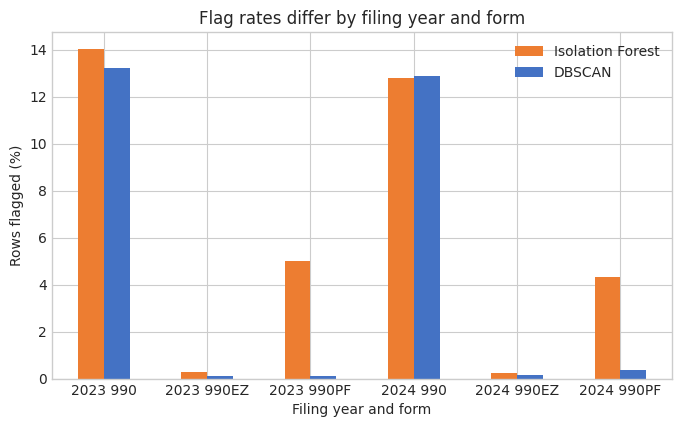

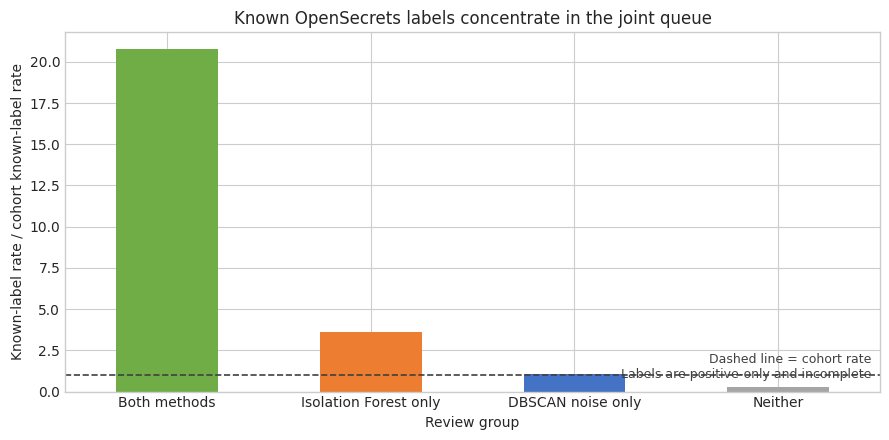

In [5]:
n_rows = len(model_results)
both_mask = (
    model_results['isolation_forest_flag']
    & model_results['dbscan_noise']
)
overlap_rows = model_results.loc[both_mask].copy()
outlier_rows = model_results.loc[
    model_results['isolation_forest_flag']
].sort_values('anomaly_score', ascending=False).copy()
outlier_rows['review_rank'] = range(1, len(outlier_rows) + 1)

overlap_summary = pd.DataFrame({
    'measure': [
        'Isolation Forest flagged',
        'DBSCAN noise',
        'Both methods',
    ],
    'rows': [
        int(model_results['isolation_forest_flag'].sum()),
        int(model_results['dbscan_noise'].sum()),
        len(overlap_rows),
    ],
})
overlap_summary['share_of_cohort'] = (
    overlap_summary['rows'] / n_rows
)
display(overlap_summary)

review_columns = [
    'review_rank',
    'filing_id',
    'ein',
    'tax_year',
    'filer_name',
    'form_type',
    'index_score',
    'anomaly_score',
    'cluster_label',
    'total_expenses',
    'total_granted',
    'num_contractors',
    'total_trxns',
    'mission_words',
]
display(outlier_rows[review_columns].head(20))

review_group_summary = (
    model_results.groupby('review_group', observed=False)
    .agg(
        rows=('filing_id', 'size'),
        median_index_score=('index_score', 'median'),
        median_expenses=('total_expenses', 'median'),
        median_grants=('total_granted', 'median'),
    )
    .sort_values('rows', ascending=False)
)
review_group_summary['share_of_cohort'] = (
    review_group_summary['rows'] / n_rows
)
display(review_group_summary)

report_features = [
    'grants_as_rev_frac',
    'perc_ind_voting_members',
    'index_score',
    'total_expenses',
    'total_granted',
    'total_lobbying_expenditures_amt',
    'total_trxns',
    'num_officers',
    'lifetime_avg_address_changes',
    'mission_words',
]
baseline_medians = pd.DataFrame({
    'cohort_median': model_results[report_features].median(),
    'both_methods_median': overlap_rows[report_features].median(),
})
baseline_medians['median_difference'] = (
    baseline_medians['both_methods_median']
    - baseline_medians['cohort_median']
)
display(
    baseline_medians.sort_values(
        'median_difference', key=lambda values: values.abs(),
        ascending=False
    )
)

by_form = (
    model_results.groupby('form_type', observed=False)
    .agg(
        rows=('filing_id', 'size'),
        isolation_forest_flags=('isolation_forest_flag', 'sum'),
        dbscan_noise=('dbscan_noise', 'sum'),
    )
)
by_form['isolation_flag_pct'] = (
    by_form['isolation_forest_flags'] / by_form['rows']
)
by_form['dbscan_noise_pct'] = by_form['dbscan_noise'] / by_form['rows']
display(by_form)

by_year = (
    model_results.groupby('tax_year', observed=False)
    .agg(
        rows=('filing_id', 'size'),
        isolation_forest_flags=('isolation_forest_flag', 'sum'),
        dbscan_noise=('dbscan_noise', 'sum'),
        known_OpenSecrets_labels=('open_secrets_known_label', 'sum'),
    )
)
by_year['isolation_flag_pct'] = (
    by_year['isolation_forest_flags'] / by_year['rows']
)
by_year['dbscan_noise_pct'] = by_year['dbscan_noise'] / by_year['rows']
by_year['known_label_rate'] = (
    by_year['known_OpenSecrets_labels'] / by_year['rows']
)
display(by_year)

by_year_form = (
    model_results.groupby(['tax_year', 'form_type'], observed=False)
    .agg(
        rows=('filing_id', 'size'),
        isolation_forest_flags=('isolation_forest_flag', 'sum'),
        dbscan_noise=('dbscan_noise', 'sum'),
    )
)
by_year_form['isolation_flag_pct'] = (
    by_year_form['isolation_forest_flags'] / by_year_form['rows']
)
by_year_form['dbscan_noise_pct'] = (
    by_year_form['dbscan_noise'] / by_year_form['rows']
)
display(by_year_form)

label_group_summary = (
    model_results.groupby('review_group', observed=False)
    .agg(
        rows=('filing_id', 'size'),
        known_OpenSecrets_labels=('open_secrets_known_label', 'sum'),
    )
)
label_group_summary['known_label_rate'] = (
    label_group_summary['known_OpenSecrets_labels']
    / label_group_summary['rows']
)
cohort_known_label_rate = (
    model_results['open_secrets_known_label'].mean()
)
label_group_summary['enrichment_vs_cohort'] = (
    label_group_summary['known_label_rate']
    / cohort_known_label_rate
)
label_group_summary = label_group_summary.reindex([
    'both methods',
    'isolation forest only',
    'DBSCAN noise only',
    'neither',
])
display(label_group_summary)

label_group_by_year = (
    model_results.groupby(
        ['tax_year', 'review_group'], observed=False
    )
    .agg(
        rows=('filing_id', 'size'),
        known_OpenSecrets_labels=('open_secrets_known_label', 'sum'),
    )
)
label_group_by_year['known_label_rate'] = (
    label_group_by_year['known_OpenSecrets_labels']
    / label_group_by_year['rows']
)
year_label_rates = (
    model_results.groupby('tax_year', observed=False)
    ['open_secrets_known_label'].mean()
)
label_group_by_year['enrichment_vs_year'] = (
    label_group_by_year['known_label_rate']
    / label_group_by_year.index.get_level_values('tax_year')
        .map(year_label_rates)
)
display(label_group_by_year)

ranked_by_anomaly = model_results.sort_values(
    'anomaly_score', ascending=False
).reset_index(drop=True)
known_label_rank_rows = []
for share, label in (
    (0.05, 'top 5% by Isolation Forest score'),
    (0.10, 'top 10% by Isolation Forest score'),
    (0.25, 'top 25% by Isolation Forest score'),
):
    rows = max(1, int(n_rows * share))
    known_label_rank_rows.append({
        'ranked_slice': label,
        'rows': rows,
        'known_OpenSecrets_labels': int(
            ranked_by_anomaly.head(rows)['open_secrets_known_label'].sum()
        ),
        'share_of_all_cohort_labels': (
            ranked_by_anomaly.head(rows)['open_secrets_known_label'].sum()
            / model_results['open_secrets_known_label'].sum()
        ),
    })
known_label_rank_summary = pd.DataFrame(known_label_rank_rows)
display(known_label_rank_summary)

agreement_summary = pd.DataFrame({
    'measure': [
        'Both methods / Isolation Forest flags',
        'Both methods / DBSCAN noise',
        'Both methods / all cohort rows',
    ],
    'share': [
        len(overlap_rows) / int(
            model_results['isolation_forest_flag'].sum()
        ),
        len(overlap_rows) / int(
            model_results['dbscan_noise'].sum()
        ),
        len(overlap_rows) / n_rows,
    ],
})
display(agreement_summary)

year_form_plot = by_year_form[
    ['isolation_flag_pct', 'dbscan_noise_pct']
].mul(100)
year_form_plot.index = [
    f'{tax_year} {form_type}'
    for tax_year, form_type in year_form_plot.index
]
ax = year_form_plot.plot.bar(
    figsize=(8, 4.5),
    color=['#ed7d31', '#4472c4'],
)
ax.set_title('Flag rates differ by filing year and form')
ax.set_xlabel('Filing year and form')
ax.set_ylabel('Rows flagged (%)')
ax.legend(['Isolation Forest', 'DBSCAN'])
plt.xticks(rotation=0)
plt.show()

label_plot = label_group_summary['enrichment_vs_cohort'].copy()
ax = label_plot.plot.bar(
    figsize=(9, 4.5),
    color=['#70ad47', '#ed7d31', '#4472c4', '#a5a5a5'],
)
ax.axhline(1.0, color='#404040', linewidth=1.2, linestyle='--')
ax.set_title('Known OpenSecrets labels concentrate in the joint queue')
ax.set_xlabel('Review group')
ax.set_ylabel('Known-label rate / cohort known-label rate')
ax.set_xticklabels([
    'Both methods',
    'Isolation Forest only',
    'DBSCAN noise only',
    'Neither',
], rotation=0)
ax.text(
    0.99,
    0.03,
    'Dashed line = cohort rate\n'
    'Labels are positive-only and incomplete',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    color='#404040',
)
plt.tight_layout()
plt.show()


## 5. Scope and next steps

This is a review-oriented baseline. Its most useful outputs are the feature
coverage, the DBSCAN sensitivity table, the Isolation Forest ranking, the
year-by-form flag rates, and the small set of filings on which both methods
agree.

The next iteration should fit separate models within each filing form and
year, then compare several deterministic samples. That would tell us
whether the same records remain unusual when unlike filing formats are no
longer competing in one feature space. A second practical step is to have
a researcher read a sample of the queue and record why each filing was
selected or dismissed. That is the evidence needed to decide whether the
features are finding a useful research pattern or merely differences in
reporting.

The models should not be interpreted as a dark-money detector. Large
organizations, sparse schedules, form-specific reporting, or data-quality
artifacts can all make a row easy to isolate. The transparency score is
descriptive context, not a label for either model.


In [6]:
scope = pd.DataFrame([
    {
        'analysis': 'Baseline feature generation',
        'rows': len(features),
        'details': f'{features.shape[1]:,} generated/context columns',
    },
    {
        'analysis': 'DBSCAN',
        'rows': len(model_results),
        'details': (
            f'{cluster_result.n_clusters:,} clusters; '
            f'{cluster_result.noise_count:,} noise rows'
        ),
    },
    {
        'analysis': 'Isolation Forest',
        'rows': len(model_results),
        'details': (
            f'{anomaly_result.anomaly_count:,} flags at '
            f'{ISOLATION_CONTAMINATION:.0%} contamination'
        ),
    },
    {
        'analysis': 'Overlap review queue',
        'rows': len(overlap_rows),
        'details': 'Rows flagged by both methods',
    },
])
display(scope)


,analysis,rows,details
0,Baseline feature generation,20000,88 generated/context columns
1,DBSCAN,20000,9 clusters; 822 noise rows
2,Isolation Forest,20000,"1,000 flags at 5% contamination"
3,Overlap review queue,660,Rows flagged by both methods


## What the current data says

The interpretation below describes the saved 20,000-row,
year-balanced run. The full score population is reported in the tables,
but it is not the population used for the written percentages that follow.

The model gives us a short list, not a conclusion. At the selected DBSCAN
radius, 822 of the 20,000 filings sit outside a dense neighborhood. The
Isolation Forest marks 1,000 filings because the run reserves 5% of the
cohort for review. Both methods select the same 660 filings. That overlap
is useful because it gives a researcher a smaller list to read first; it
does not mean that the two algorithms have found a single, objective
category called “unusual.”

The clearest pattern is the filing form. The two years behave similarly:
Isolation Forest marks 5.2% of the 2023 rows and 4.8% of the 2024 rows,
while DBSCAN marks 4.2% and 4.1% as noise. Form 990 is different from the
shorter 990-EZ and the 990-PF in what it asks organizations to report.
In this cohort, 13.4% of Form 990 rows are Isolation Forest flags and
13.1% are DBSCAN noise. The corresponding rates are 0.3% and 0.1% for
Form 990-EZ, and 4.7% and 0.3% for Form 990-PF. The same ordering appears
within each year. This is a strong warning that the pooled model is
responding to reporting structure and schedule availability, not only to
differences in how organizations operate. A form-specific model is the
next necessary check.

The filings selected by both methods are also much larger than the typical
filing in the cohort. Their median expenses are about $1.93 million,
compared with $69,636 for the cohort as a whole. Their median reported
lobbying expenditures are $316,000 versus $922, median grants are
$324,500 versus $49,200, and their mission statements contain 28 words
versus 14. Their median transparency-index score is 4.17 versus 3.76.
In plain terms, the shared queue is finding large, information-rich
organizations. That makes it a sensible reading list, but it does not
tell us whether those organizations are behaving improperly; size and
more complete reporting are enough to make a filing stand out.

The OpenSecrets comparison points in the same direction, with an important
limitation. The full two-year score population contains 590 labeled filing
rows representing 306 EINs: 303 rows from 2023 and 287 from 2024. We put
all of those rows into the bounded cohort, so the joint queue contains
404 known-labeled rows, or 61.2% of that queue. The top 5% of Isolation
Forest scores contains 440 known-labeled rows, or 74.6% of the labeled
rows in the cohort. This tells us that the feature set is placing many
organizations already identified by the OpenSecrets workflow near the
front of the reading list. It does not tell us that an unlabeled filing
is clean, and it does not measure how many relevant organizations the
workflow fails to identify.

Taken together, the result is a useful starting point with a narrow
interpretation. The features expose a small group of large, information-
rich filings, and the two methods often agree on those rows. But form
type and missing schedules are powerful enough to shape the queue. Before
making a substantive claim, we should rerun within forms, compare the
results across years and samples, and have a researcher read the selected
filings.
